# Credit Card Fraud Detection using Machine Learning

## Project Description
This project detects fraudulent credit card transactions using Machine Learning algorithms. It uses Logistic Regression to classify transactions as fraudulent or genuine.

**Algorithm Used:**
- Logistic Regression

**Language:**
- Python

**Libraries:**
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Dataset

**Source:** Kaggle - Credit Card Fraud Detection Dataset

**Dataset Link:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**Details:**
- Total Transactions: 284,807
- Fraudulent Transactions: 492
- Normal Transactions: 284,315
- Features: 31 (Time, V1-V28, Amount, Class)

**Target Variable:**
- 0 = Normal
- 1 = Fraud

## Project Workflow

1. Import required libraries
2. Load the dataset
3. Explore and understand the data
4. Check for missing values
5. Split the dataset into training and testing sets
6. Train the Logistic Regression model
7. Predict fraud transactions
8. Evaluate the model using accuracy and confusion matrix
9. Save the trained model

## Results

### Logistic Regression
- Accuracy: 99.89%

### Confusion Matrix
The model correctly classified almost all genuine transactions and detected fraudulent transactions with high accuracy.

### Classification Report
- Precision: High
- Recall: Good
- F1-Score: Good

## Conclusion

This project successfully detects fraudulent credit card transactions using Machine Learning. Logistic Regression achieved an accuracy of approximately 99.89%. Although the dataset is highly imbalanced, the model performs well and can be further improved using techniques such as SMOTE, XGBoost, or Deep Learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

Shape: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


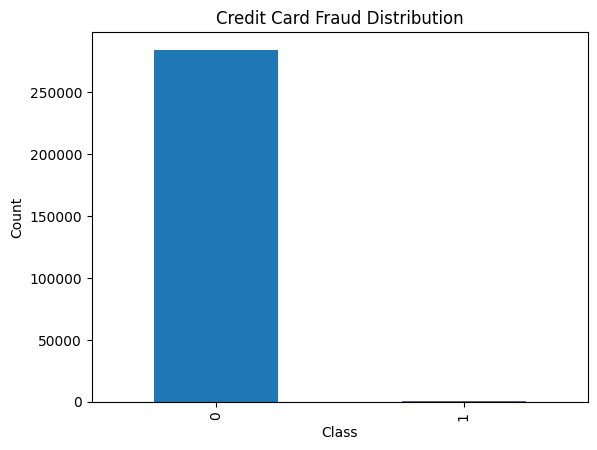

In [5]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')

plt.title("Credit Card Fraud Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [6]:
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]

print("Fraud Transactions:", fraud)
print("Normal Transactions:", normal)

print("Fraud Percentage:", (fraud / len(df)) * 100)

Fraud Transactions: 492
Normal Transactions: 284315
Fraud Percentage: 0.1727485630620034


In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\nanim\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9989291106351603

Confusion Matrix:

[[56852    12]
 [   49    49]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.50      0.62        98

    accuracy                           1.00     56962
   macro avg       0.90      0.75      0.81     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

   Feature  Importance
14     V14    0.196692
17     V17    0.191922
12     V12    0.091905
10     V10    0.069622
16     V16    0.069396
7       V7    0.030478
9       V9    0.029280
18     V18    0.026907
4       V4    0.022102
11     V11    0.021759


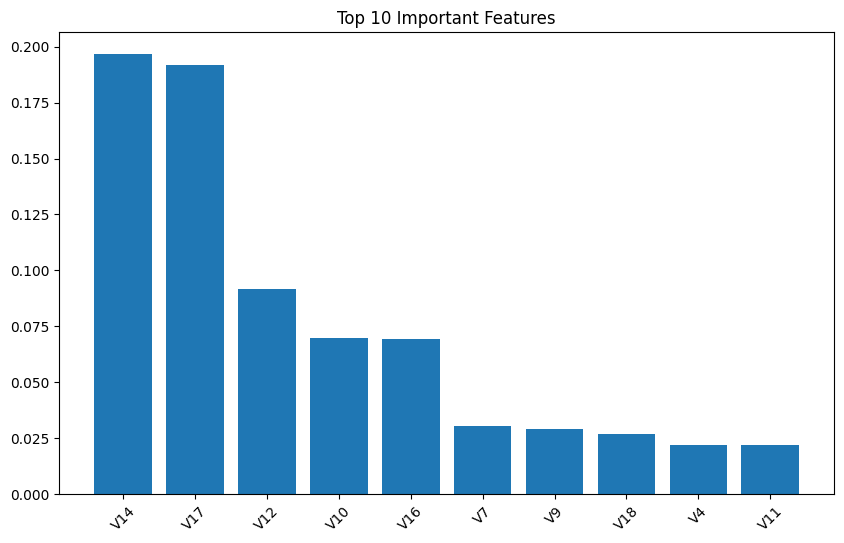

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.bar(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.show()

In [16]:
import joblib

joblib.dump(rf_model, "credit_card_fraud_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [17]:
loaded_model = joblib.load("credit_card_fraud_model.pkl")

prediction = loaded_model.predict(X_test.iloc[:5])

print(prediction)

[1 0 0 0 0]


In [18]:
import os
print(os.getcwd())

C:\Users\nanim
